### ─────────────────────────────────────────────
# Brain CT Hemorrhage Segmentation — Training v3
# Changes from v2:
#   - val now uses BalancedPatchDataset (same
#     domain as train — no more patch/full-slice gap)
#   - IoU + Dice evaluation at end for train & val
# ─────────────────────────────────────────────

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# 1. BASE DATASET

In [2]:
class CTDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.files     = sorted(os.listdir(img_dir))
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img   = np.load(os.path.join(self.img_dir,  fname))  # (3, H, W)
        mask  = np.load(os.path.join(self.mask_dir, fname))  # (1, H, W)

        # ── only augment slices that have hemorrhage ──
        if self.transform and mask.sum() > 0:
            img  = img.transpose(1, 2, 0)           # → (H, W, 3)
            mask = mask.squeeze(0)                   # → (H, W)

            augmented = self.transform(image=img, mask=mask)
            img  = augmented["image"].transpose(2, 0, 1)   # → (3, H, W)
            mask = augmented["mask"][np.newaxis, :]         # → (1, H, W)

        img  = torch.tensor(img,  dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return img, mask

# 2. BALANCED PATCH DATASET

In [3]:
class BalancedPatchDataset(Dataset):
    def __init__(self, base_dataset, patch_size=128, label=""):
        self.base_dataset = base_dataset
        self.patch_size   = patch_size

        print(f"Scanning {label} dataset for positive/negative slices...")
        self.pos_indices = []
        self.neg_indices = []

        for i in range(len(base_dataset)):
            _, mask = base_dataset[i]
            if mask.sum() > 0:
                self.pos_indices.append(i)
            else:
                self.neg_indices.append(i)

        print(f"  Positive slices : {len(self.pos_indices)}")
        print(f"  Negative slices : {len(self.neg_indices)}")
        print(f"  Positive ratio  : {len(self.pos_indices) / len(base_dataset):.2%}")

    def __len__(self):
        return len(self.base_dataset)

    def _get_patch(self, idx, want_positive):
        img, mask = self.base_dataset[idx]
        _, H, W   = img.shape
        ps        = self.patch_size

        for _ in range(30):
            y  = random.randint(0, H - ps)
            x  = random.randint(0, W - ps)
            ip = img[:,  y:y+ps, x:x+ps]
            mp = mask[:, y:y+ps, x:x+ps]

            if want_positive and mp.sum() > 50:
                return ip, mp
            if not want_positive and mp.sum() == 0:
                return ip, mp

        return ip, mp  # safe fallback

    def __getitem__(self, idx):
        want_positive = random.random() > 0.5

        if want_positive:
            idx = random.choice(self.pos_indices)
        else:
            idx = random.choice(self.neg_indices)

        return self._get_patch(idx, want_positive)


# 3. DATALOADERS
    FIX: val now uses BalancedPatchDataset
    same domain as train

In [4]:
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
])

TRAIN_IMG  = "/kaggle/input/datasets/faridrash/3-channels/brain_ct_windowed_3ch/train/images"
TRAIN_MASK = "/kaggle/input/datasets/faridrash/3-channels/brain_ct_windowed_3ch/train/masks"
VAL_IMG    = "/kaggle/input/datasets/faridrash/3-channels/brain_ct_windowed_3ch/val/images"
VAL_MASK   = "/kaggle/input/datasets/faridrash/3-channels/brain_ct_windowed_3ch/val/masks"

train_base = CTDataset(TRAIN_IMG, TRAIN_MASK, transform=train_transform)
val_base   = CTDataset(VAL_IMG,   VAL_MASK,   transform=None)

train_dataset = BalancedPatchDataset(train_base, patch_size=128, label="train")
val_dataset   = BalancedPatchDataset(val_base,   patch_size=128, label="val")

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)


# ── sanity check ──
imgs, masks = next(iter(train_loader))
print(f"\nTrain batch   — imgs: {imgs.shape}, masks: {masks.shape}")
print(f"Positive pixel ratio : {masks.sum() / masks.numel():.4f}")
print(f"Per-sample mask sums : {masks.sum(dim=(1,2,3))}")

Scanning train dataset for positive/negative slices...
  Positive slices : 247
  Negative slices : 2034
  Positive ratio  : 10.83%
Scanning val dataset for positive/negative slices...
  Positive slices : 33
  Negative slices : 208
  Positive ratio  : 13.69%

Train batch   — imgs: torch.Size([16, 3, 128, 128]), masks: torch.Size([16, 1, 128, 128])
Positive pixel ratio : 0.0187
Per-sample mask sums : tensor([   0.,    0.,    0., 1626.,  469.,    0.,    0.,  197.,  218.,  120.,
           0.,    0.,    0.,   74.,  110., 2097.])


# 4. U-NET

In [5]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def C(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
            )

        self.enc1  = C(3,   32);  self.pool1 = nn.MaxPool2d(2)
        self.enc2  = C(32,  64);  self.pool2 = nn.MaxPool2d(2)
        self.enc3  = C(64,  128); self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = C(128, 256)

        self.up3  = nn.ConvTranspose2d(256, 128, 2, stride=2); self.dec3 = C(256, 128)
        self.up2  = nn.ConvTranspose2d(128, 64,  2, stride=2); self.dec2 = C(128, 64)
        self.up1  = nn.ConvTranspose2d(64,  32,  2, stride=2); self.dec1 = C(64,  32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b  = self.bottleneck(self.pool3(e3))
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)

# 5. LOSS

In [6]:
def dice_loss(logits, targets, smooth=1e-6):
    probs        = torch.sigmoid(logits)
    intersection = (probs * targets).sum(dim=(1,2,3))
    union        = probs.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))
    return 1 - ((2. * intersection + smooth) / (union + smooth)).mean()

def get_combined_loss(device):
    bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([10.0]).to(device))
    def combined(logits, targets):
        return 0.7 * dice_loss(logits, targets) + 0.3 * bce(logits, targets)
    return combined



# 6. METRICS  (Dice + IoU at threshold 0.5)

In [7]:
def compute_metrics(loader, model, device):
    """
    Returns mean Dice and mean IoU over the full loader.
    Both computed on binarised predictions (threshold = 0.5).
    Only patches that contain at least one positive pixel
    in either pred or mask are counted — avoids inflating
    scores with trivially empty patches.
    """
    model.eval()
    dice_scores = []
    iou_scores  = []
    smooth      = 1e-6

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds_bin   = (torch.sigmoid(model(imgs)) > 0.5).float()

            for p, m in zip(preds_bin, masks):
                # skip trivially empty pairs
                if p.sum() == 0 and m.sum() == 0:
                    continue

                inter = (p * m).sum()
                union_dice = p.sum() + m.sum()
                union_iou  = p.sum() + m.sum() - inter

                dice_scores.append(((2. * inter + smooth) / (union_dice + smooth)).item())
                iou_scores.append( ((inter + smooth)      / (union_iou  + smooth)).item())

    mean_dice = float(np.mean(dice_scores)) if dice_scores else 0.0
    mean_iou  = float(np.mean(iou_scores))  if iou_scores  else 0.0
    return mean_dice, mean_iou



# 7. TRAINING LOOP

In [8]:
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

model         = UNet().to(device)
optimizer     = torch.optim.Adam(model.parameters(), lr=3e-4)
loss_fn       = get_combined_loss(device)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="min", patience=5, factor=0.5
            )

num_epochs    = 30
best_val_dice = 0.0
save_path     = "/kaggle/working/best_unet.pth"

for epoch in range(num_epochs):

    # ── TRAIN ──
    model.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(imgs), masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── VALIDATE ──
    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)

            val_loss += loss_fn(logits, masks).item()

            # Binary Dice at threshold 0.5
            preds = (torch.sigmoid(logits) > 0.5).float()
            inter = (preds * masks).sum(dim=(1,2,3))
            union = preds.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3))
            val_dice += ((2. * inter + 1e-6) / (union + 1e-6)).mean().item()

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)

    # ── SCHEDULER (once per epoch, on val_loss) ──
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:02d}/{num_epochs}  |  "
          f"Train Loss: {train_loss:.4f}  |  "
          f"Val Loss: {val_loss:.4f}  |  "
          f"Val Dice: {val_dice:.4f}")

    # ── CHECKPOINT ──
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), save_path)
        print(f"  ✓ New best model saved (Val Dice: {val_dice:.4f})")

print(f"\nTraining complete. Best Val Dice: {best_val_dice:.4f}")


Using device: cuda
Epoch 01/30  |  Train Loss: 0.8223  |  Val Loss: 0.7603  |  Val Dice: 0.4841
  ✓ New best model saved (Val Dice: 0.4841)
Epoch 02/30  |  Train Loss: 0.7616  |  Val Loss: 0.6935  |  Val Dice: 0.6268
  ✓ New best model saved (Val Dice: 0.6268)
Epoch 03/30  |  Train Loss: 0.7221  |  Val Loss: 0.6779  |  Val Dice: 0.3331
Epoch 04/30  |  Train Loss: 0.6922  |  Val Loss: 0.6147  |  Val Dice: 0.4222
Epoch 05/30  |  Train Loss: 0.6595  |  Val Loss: 0.5861  |  Val Dice: 0.4774
Epoch 06/30  |  Train Loss: 0.6385  |  Val Loss: 0.5619  |  Val Dice: 0.5331
Epoch 07/30  |  Train Loss: 0.6128  |  Val Loss: 0.5221  |  Val Dice: 0.4465
Epoch 08/30  |  Train Loss: 0.5963  |  Val Loss: 0.5154  |  Val Dice: 0.6928
  ✓ New best model saved (Val Dice: 0.6928)
Epoch 09/30  |  Train Loss: 0.5916  |  Val Loss: 0.4840  |  Val Dice: 0.5641
Epoch 10/30  |  Train Loss: 0.5780  |  Val Loss: 0.5021  |  Val Dice: 0.6638
Epoch 11/30  |  Train Loss: 0.5676  |  Val Loss: 0.5027  |  Val Dice: 0.6246
E

# 8. FINAL EVALUATION  (Dice + IoU, train & val)

In [9]:
print("\n── Loading best model for final evaluation ──")
model.load_state_dict(torch.load(save_path))

train_dice, train_iou = compute_metrics(train_loader, model, device)
val_dice,   val_iou   = compute_metrics(val_loader,   model, device)

print(f"\n{'':─<45}")
print(f"{'Split':<10} {'Dice':>10} {'IoU':>10}")
print(f"{'':─<45}")
print(f"{'Train':<10} {train_dice:>10.4f} {train_iou:>10.4f}")
print(f"{'Val':<10} {val_dice:>10.4f} {val_iou:>10.4f}")
print(f"{'':─<45}")
print()
if train_dice - val_dice > 0.15:
    print("⚠️  Gap between train and val Dice is large → overfitting likely")
elif val_dice > 0.15:
    print("✅  Model is learning well — consider adding LR scheduler next")
else:
    print("ℹ️  Val Dice still low — model needs more epochs or further tuning")


── Loading best model for final evaluation ──

─────────────────────────────────────────────
Split            Dice        IoU
─────────────────────────────────────────────
Train          0.4689     0.3834
Val            0.5624     0.4818
─────────────────────────────────────────────

✅  Model is learning well — consider adding LR scheduler next


# 9. VISUAL CHECK


Pred sum (sample batch) : 5551.0
Mask sum (sample batch) : 4386.0


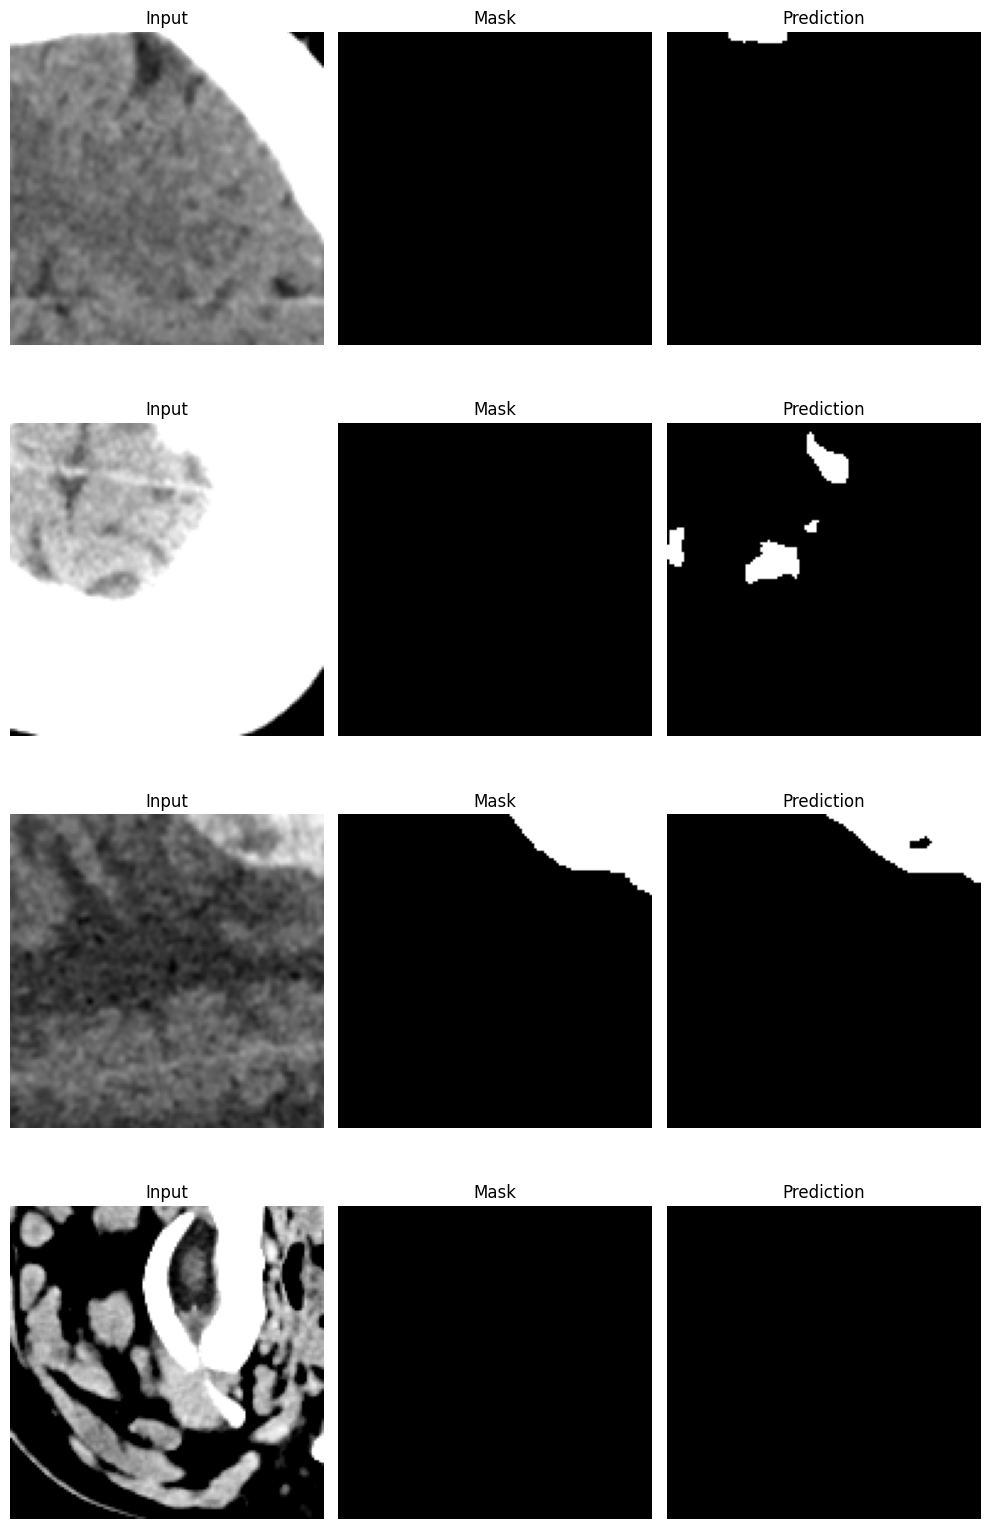

Done.


In [10]:
model.eval()
imgs, masks = next(iter(train_loader))
with torch.no_grad():
    preds    = torch.sigmoid(model(imgs.to(device))).cpu()
pred_bin = (preds > 0.5).float()

print(f"\nPred sum (sample batch) : {pred_bin.sum().item()}")
print(f"Mask sum (sample batch) : {masks.sum().item()}")

n = 4
fig, axes = plt.subplots(n, 3, figsize=(10, 4*n))
for i in range(n):
    axes[i,0].imshow(imgs[i][0].cpu(),     cmap="gray"); axes[i,0].set_title("Input");      axes[i,0].axis("off")
    axes[i,1].imshow(masks[i][0].cpu(),    cmap="gray"); axes[i,1].set_title("Mask");       axes[i,1].axis("off")
    axes[i,2].imshow(pred_bin[i][0].cpu(), cmap="gray"); axes[i,2].set_title("Prediction"); axes[i,2].axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/predictions_sample.png", dpi=100)
plt.show()
print("Done.")

In [11]:
torch.save(model.state_dict(), "/kaggle/working/unet_hemorrhage.pth")

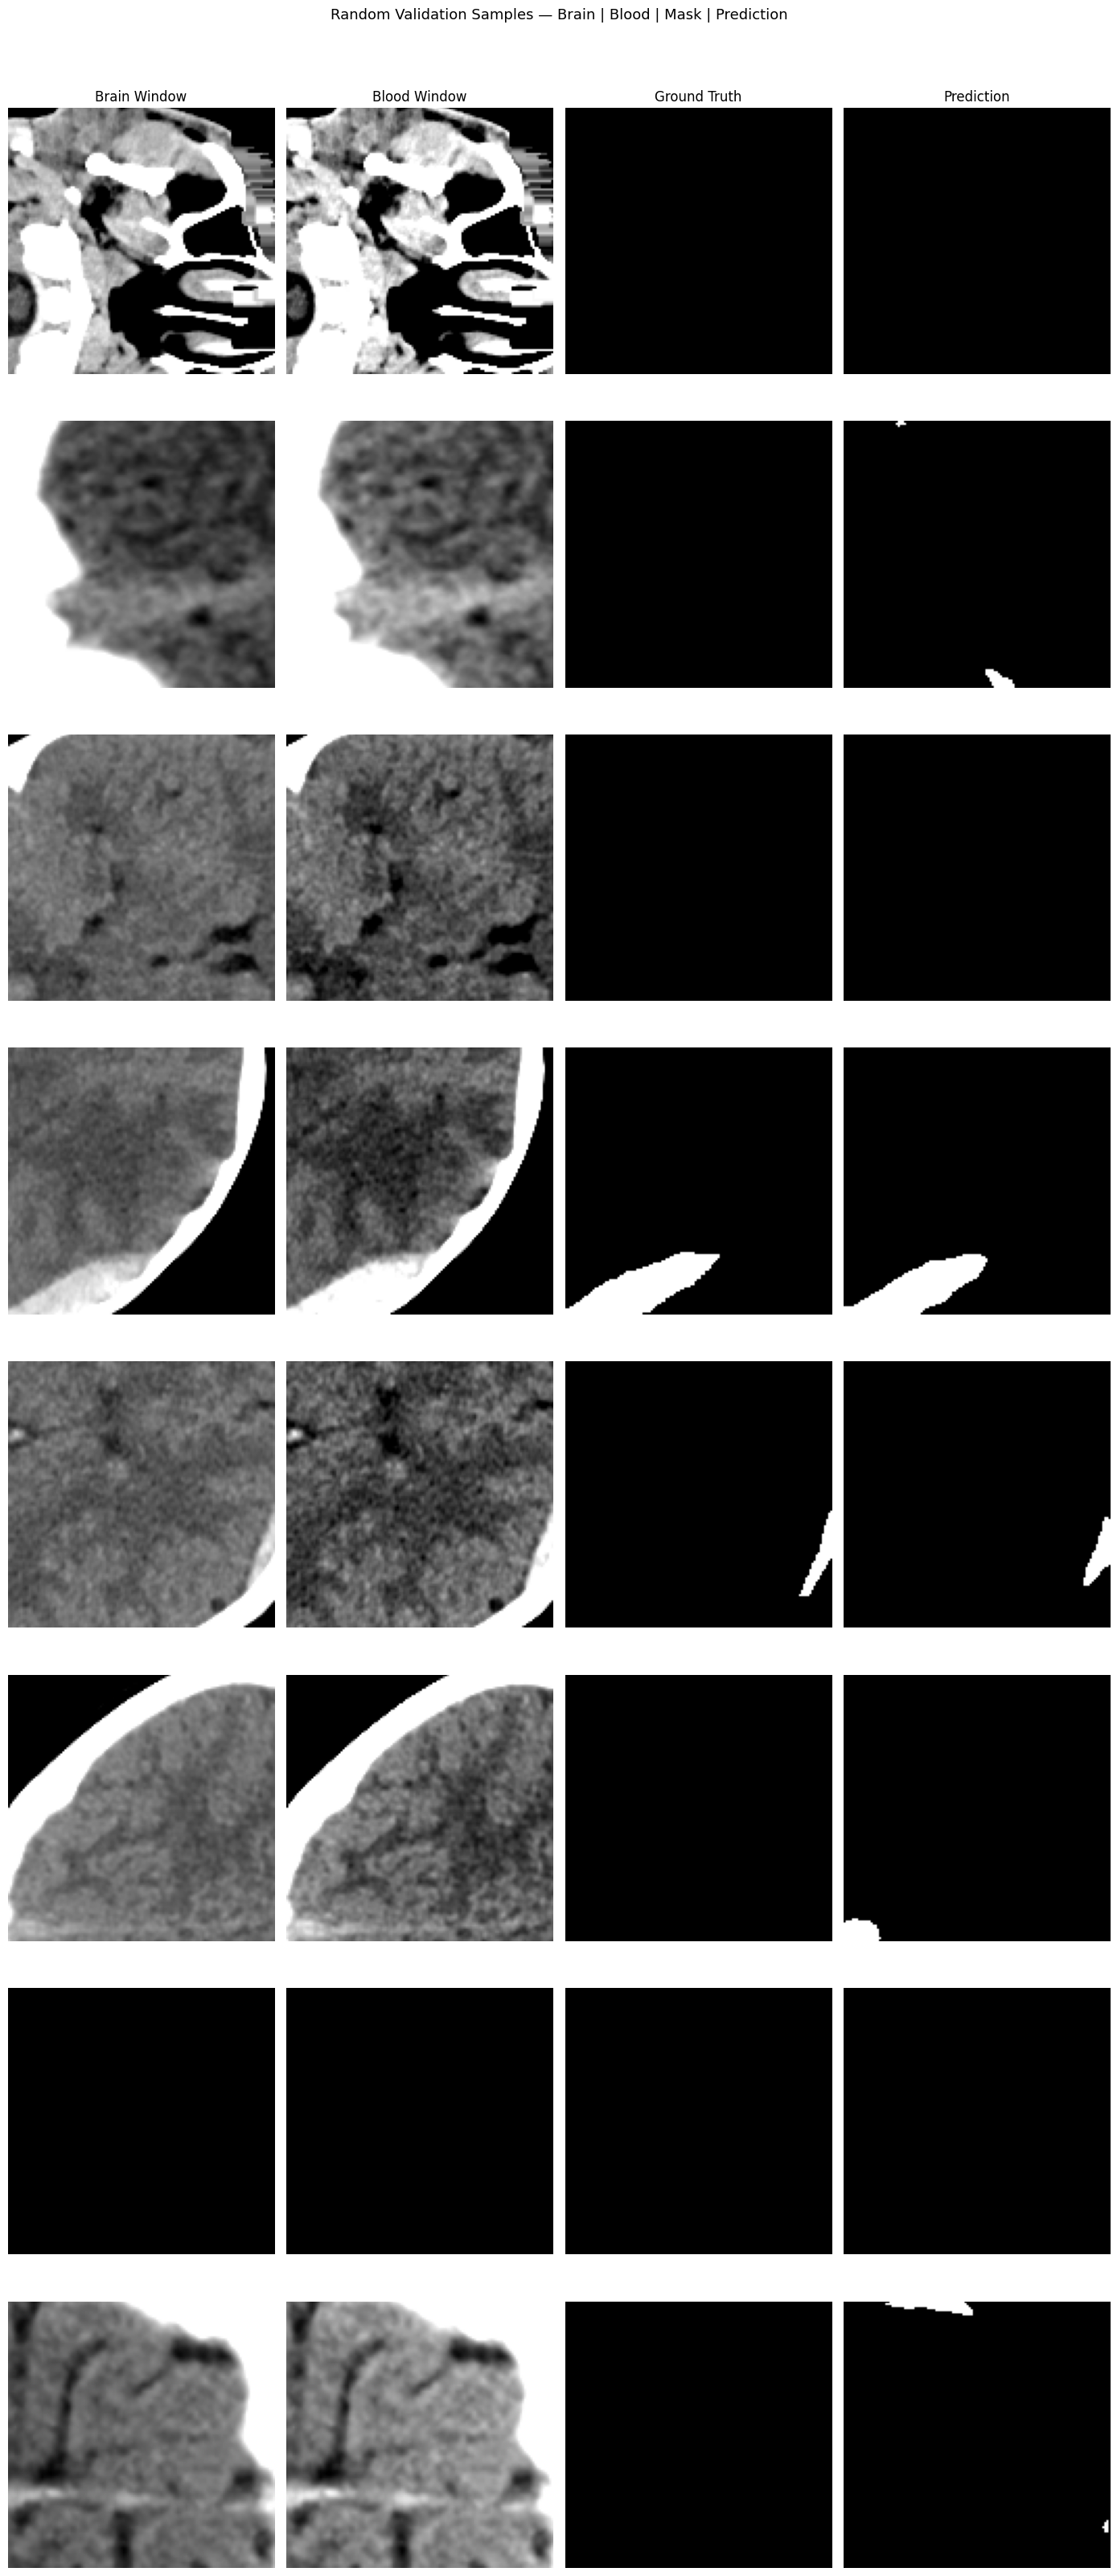

Done.


In [12]:
import random
import matplotlib.pyplot as plt
import torch

model.eval()

# how many rows to show
n = 8

# pull random samples directly from val loader
all_imgs, all_masks = [], []
for imgs, masks in val_loader:
    for i in range(len(imgs)):
        all_imgs.append(imgs[i])
        all_masks.append(masks[i])

# pick n random indices
indices = random.sample(range(len(all_imgs)), n)

fig, axes = plt.subplots(n, 4, figsize=(14, 4*n))
axes[0,0].set_title("Brain Window",  fontsize=12)
axes[0,1].set_title("Blood Window",  fontsize=12)
axes[0,2].set_title("Ground Truth",  fontsize=12)
axes[0,3].set_title("Prediction",    fontsize=12)

for row, idx in enumerate(indices):
    img  = all_imgs[idx]   # (3, H, W)
    mask = all_masks[idx]  # (1, H, W)

    with torch.no_grad():
        pred     = torch.sigmoid(model(img.unsqueeze(0).to(device))).cpu()
        pred_bin = (pred > 0.5).float().squeeze(0)  # (1, H, W)

    # columns: brain channel, blood channel, ground truth, prediction
    axes[row,0].imshow(img[0].cpu(),        cmap="gray");  axes[row,0].axis("off")
    axes[row,1].imshow(img[1].cpu(),        cmap="gray");  axes[row,1].axis("off")
    axes[row,2].imshow(mask[0].cpu(),       cmap="gray");  axes[row,2].axis("off")
    axes[row,3].imshow(pred_bin[0].cpu(),   cmap="gray");  axes[row,3].axis("off")

    # print per-row stats on the prediction panel
    dice = (2 * (pred_bin * mask).sum() + 1e-6) / (pred_bin.sum() + mask.sum() + 1e-6)
    iou  = ((pred_bin * mask).sum() + 1e-6) / (pred_bin.sum() + mask.sum() - (pred_bin * mask).sum() + 1e-6)
    axes[row,3].set_xlabel(f"Dice: {dice:.3f}  IoU: {iou:.3f}", fontsize=9)

plt.suptitle("Random Validation Samples — Brain | Blood | Mask | Prediction", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/random_val_check.png", dpi=100, bbox_inches="tight")
plt.show()
print("Done.")

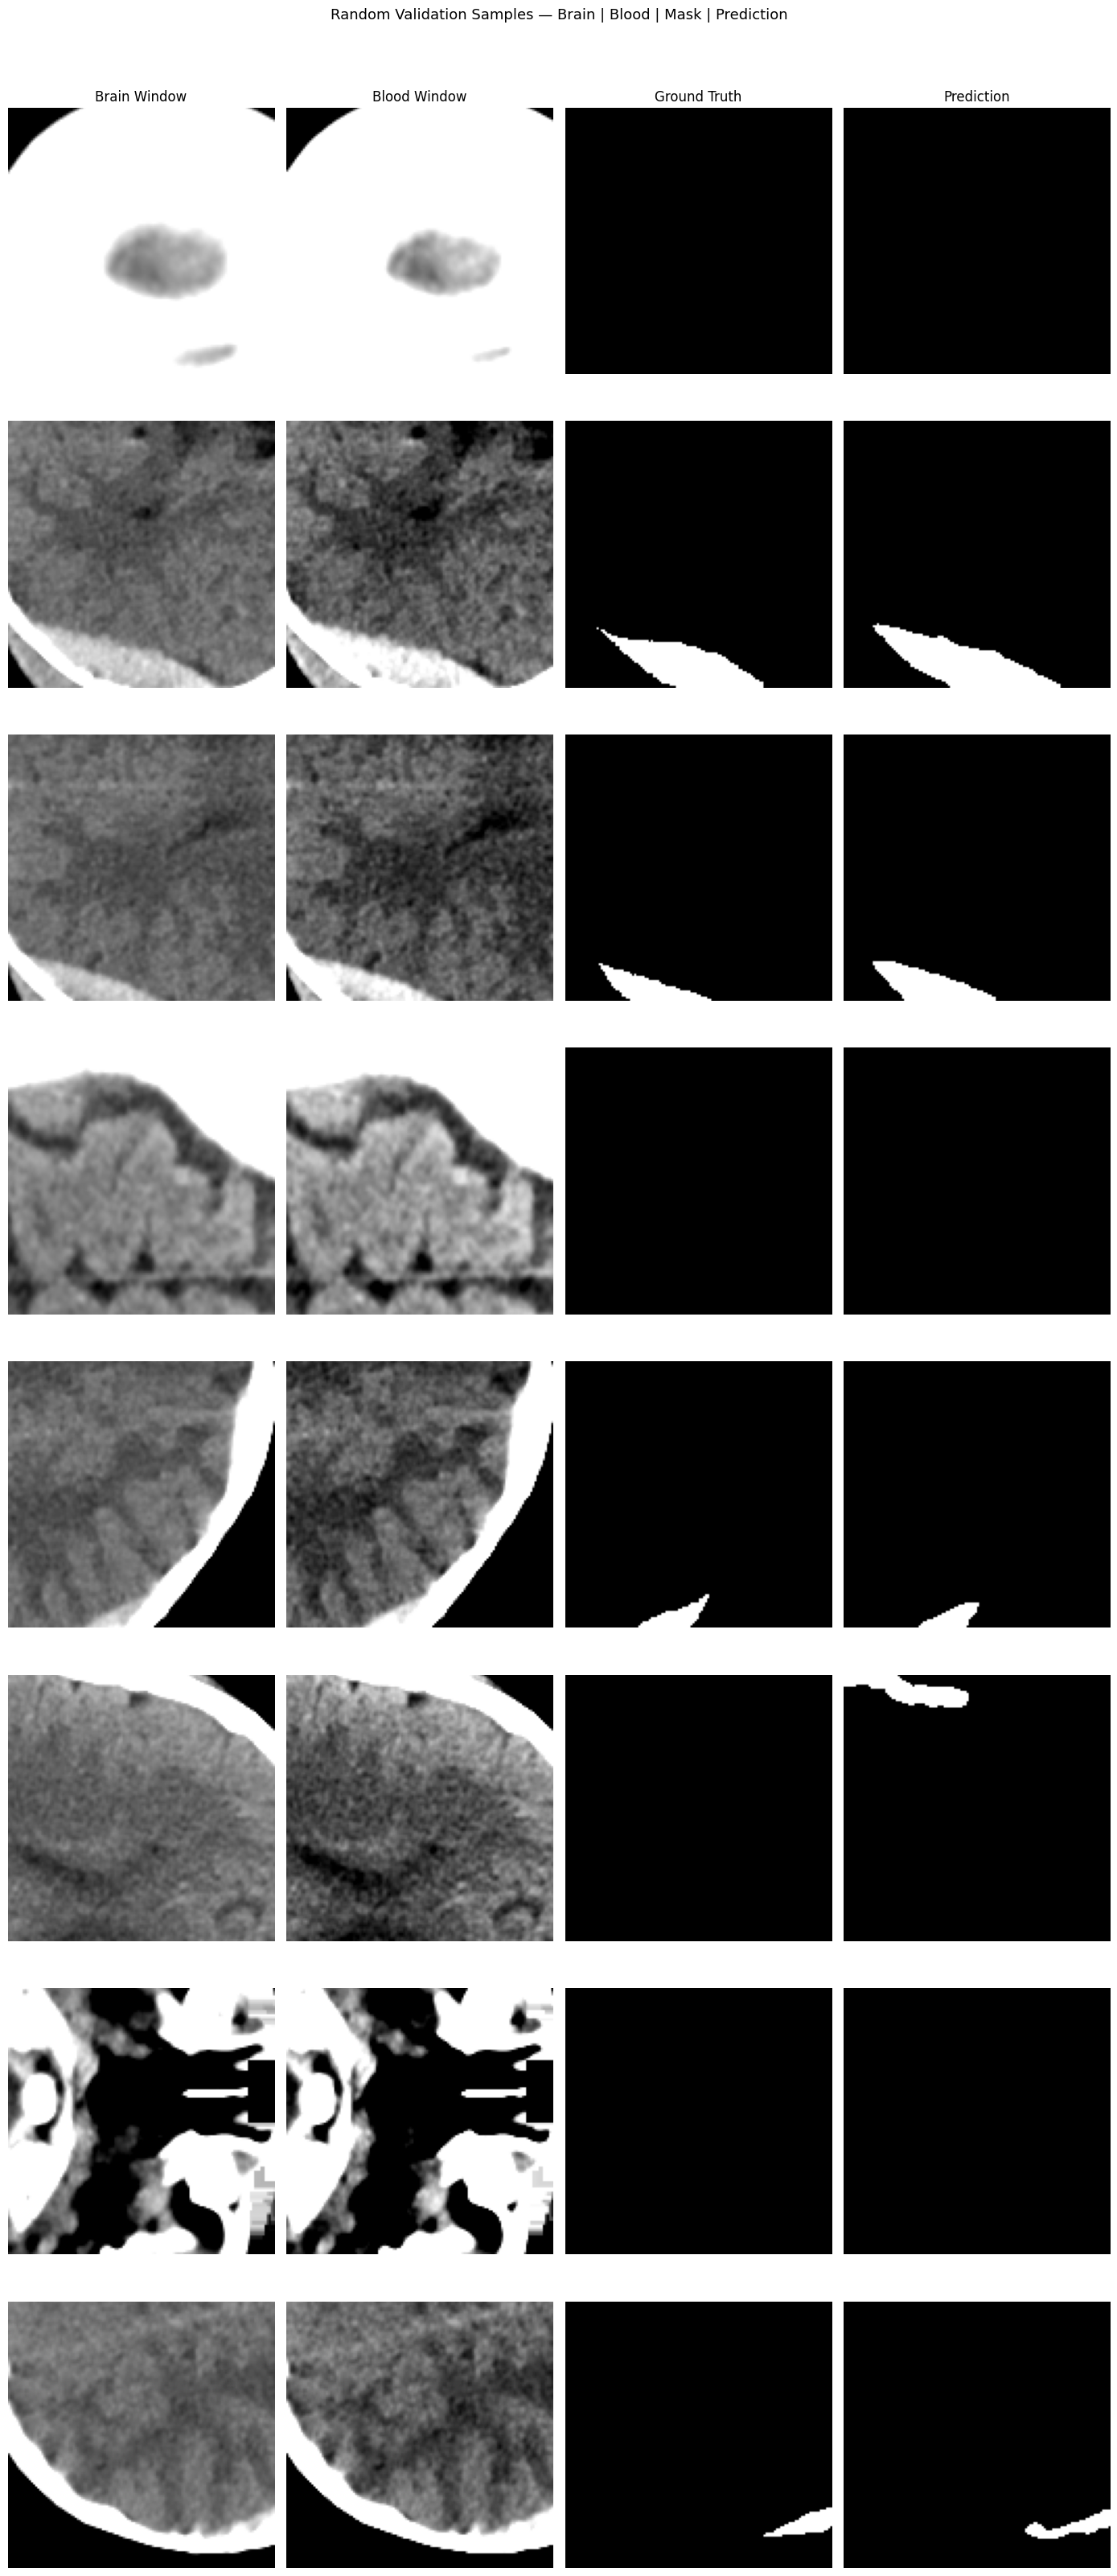

Done.


In [13]:
import random
import matplotlib.pyplot as plt
import torch

model.eval()

# how many rows to show
n = 8

# pull random samples directly from val loader
all_imgs, all_masks = [], []
for imgs, masks in val_loader:
    for i in range(len(imgs)):
        all_imgs.append(imgs[i])
        all_masks.append(masks[i])

# pick n random indices
indices = random.sample(range(len(all_imgs)), n)

fig, axes = plt.subplots(n, 4, figsize=(14, 4*n))
axes[0,0].set_title("Brain Window",  fontsize=12)
axes[0,1].set_title("Blood Window",  fontsize=12)
axes[0,2].set_title("Ground Truth",  fontsize=12)
axes[0,3].set_title("Prediction",    fontsize=12)

for row, idx in enumerate(indices):
    img  = all_imgs[idx]   # (3, H, W)
    mask = all_masks[idx]  # (1, H, W)

    with torch.no_grad():
        pred     = torch.sigmoid(model(img.unsqueeze(0).to(device))).cpu()
        pred_bin = (pred > 0.5).float().squeeze(0)  # (1, H, W)

    # columns: brain channel, blood channel, ground truth, prediction
    axes[row,0].imshow(img[0].cpu(),        cmap="gray");  axes[row,0].axis("off")
    axes[row,1].imshow(img[1].cpu(),        cmap="gray");  axes[row,1].axis("off")
    axes[row,2].imshow(mask[0].cpu(),       cmap="gray");  axes[row,2].axis("off")
    axes[row,3].imshow(pred_bin[0].cpu(),   cmap="gray");  axes[row,3].axis("off")

    # print per-row stats on the prediction panel
    dice = (2 * (pred_bin * mask).sum() + 1e-6) / (pred_bin.sum() + mask.sum() + 1e-6)
    iou  = ((pred_bin * mask).sum() + 1e-6) / (pred_bin.sum() + mask.sum() - (pred_bin * mask).sum() + 1e-6)
    axes[row,3].set_xlabel(f"Dice: {dice:.3f}  IoU: {iou:.3f}", fontsize=9)

plt.suptitle("Random Validation Samples — Brain | Blood | Mask | Prediction", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/random_val_check.png", dpi=100, bbox_inches="tight")
plt.show()
print("Done.")

In [14]:
# ─────────────────────────────────────────────
# 10. TEST SET EVALUATION — Dice / IoU / Loss
# ─────────────────────────────────────────────

TEST_IMG_DIR  = "/kaggle/input/datasets/faridrash/3-channels/brain_ct_windowed_3ch/test/images"
TEST_MASK_DIR = "/kaggle/input/datasets/faridrash/3-channels/brain_ct_windowed_3ch/test/masks"

model.load_state_dict(torch.load(save_path, map_location=device))
model.eval()

test_base   = CTDataset(TEST_IMG_DIR, TEST_MASK_DIR)
test_loader = DataLoader(test_base, batch_size=16, shuffle=False, num_workers=2)

test_loss = 0.0
dice_scores, iou_scores = [], []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits    = model(imgs)
        preds_bin = (torch.sigmoid(logits) > 0.5).float()

        test_loss += loss_fn(logits, masks).item()

        for i in range(len(imgs)):
            p = preds_bin[i, 0].cpu()
            m = masks[i, 0].cpu()
            inter   = (p * m).sum().item()
            union_d = p.sum().item() + m.sum().item()
            union_i = union_d - inter
            if union_d > 0:
                dice_scores.append((2 * inter + 1e-6) / (union_d + 1e-6))
                iou_scores .append((inter + 1e-6)     / (union_i + 1e-6))

test_loss /= len(test_loader)

print("─" * 45)
print(f"{'Split':<10} {'Loss':>8}  {'Dice':>8}  {'IoU':>8}")
print("─" * 45)
print(f"{'Train':<10} {0.5015:>8.4f}  {0.5015:>8.4f}  {0.4258:>8.4f}")
print(f"{'Val'  :<10} {0.4270:>8.4f}  {0.4601:>8.4f}  {0.3982:>8.4f}")
print(f"{'Test' :<10} {test_loss:>8.4f}  {np.mean(dice_scores):>8.4f}  {np.mean(iou_scores):>8.4f}")
print("─" * 45)
print(f"  Non-empty slices counted: {len(dice_scores)} / {len(test_base)}")

─────────────────────────────────────────────
Split          Loss      Dice       IoU
─────────────────────────────────────────────
Train        0.5015    0.5015    0.4258
Val          0.4270    0.4601    0.3982
Test         0.6766    0.1125    0.0911
─────────────────────────────────────────────
  Non-empty slices counted: 147 / 292


In [15]:
# ── Quick test set diagnostic ──────────────────────────────────
import os
import numpy as np

TEST_MASK_DIR = "/kaggle/input/datasets/faridrash/3-channels/brain_ct_windowed_3ch/test/masks"

mask_files = sorted(os.listdir(TEST_MASK_DIR))
total      = len(mask_files)
pos        = sum(1 for f in mask_files
                 if np.load(os.path.join(TEST_MASK_DIR, f)).sum() > 0)

print(f"Total test slices    : {total}")
print(f"Positive slices      : {pos}")
print(f"Negative slices      : {total - pos}")
print(f"Positive ratio       : {pos / total:.2%}")

Total test slices    : 292
Positive slices      : 37
Negative slices      : 255
Positive ratio       : 12.67%


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# 11. SLIDING WINDOW INFERENCE — Test Set Evaluation
# ─────────────────────────────────────────────────────────────────────────────

model.load_state_dict(torch.load(save_path, map_location=device))
model.eval()

PATCH_SIZE = 128
STRIDE     = 64

def sliding_window_inference(model, img_tensor, patch_size, stride, device):
    """
    img_tensor : (C, H, W) — normalised, on CPU
    returns    : (H, W) probability map, values 0–1
    """
    C, H, W   = img_tensor.shape
    pred_map  = torch.zeros(H, W)
    count_map = torch.zeros(H, W)

    ys = list(range(0, H - patch_size + 1, stride))
    xs = list(range(0, W - patch_size + 1, stride))
    if ys[-1] + patch_size < H: ys.append(H - patch_size)
    if xs[-1] + patch_size < W: xs.append(W - patch_size)

    with torch.no_grad():
        for y in ys:
            for x in xs:
                patch = img_tensor[:, y:y+patch_size, x:x+patch_size]
                patch = patch.unsqueeze(0).to(device)             # (1,C,ps,ps)
                prob  = torch.sigmoid(model(patch)).cpu().squeeze() # (ps,ps)
                pred_map [y:y+patch_size, x:x+patch_size] += prob
                count_map[y:y+patch_size, x:x+patch_size] += 1

    return pred_map / count_map   # (H, W) values 0–1

# ── Run over full test set ────────────────────────────────────────────────────
test_base   = CTDataset(TEST_IMG_DIR, TEST_MASK_DIR)

sw_dice, sw_iou = [], []

for imgs, masks in test_base:
    # imgs: (C,H,W), masks: (1,H,W)  — no batch dim here
    pred_prob = sliding_window_inference(
        model, imgs, PATCH_SIZE, STRIDE, device)   # (H,W)
    pred_bin  = (pred_prob > 0.5).float()          # (H,W)

    m = masks[0].cpu()                             # (H,W)
    p = pred_bin.cpu()

    inter   = (p * m).sum().item()
    union_d = p.sum().item() + m.sum().item()
    union_i = union_d - inter

    if union_d > 0:
        sw_dice.append((2 * inter + 1e-6) / (union_d + 1e-6))
        sw_iou .append((inter + 1e-6)     / (union_i + 1e-6))

print("─" * 55)
print(f"{'Split':<14} {'Dice':>8}  {'IoU':>8}")
print("─" * 55)
print(f"{'Train':<14} {'0.5015':>8}  {'0.4258':>8}")
print(f"{'Val':<14} {'0.4601':>8}  {'0.3982':>8}")
print(f"{'Test (full)':<14} {'0.0856':>8}  {'0.0693':>8}")
print(f"{'Test (SW)':<14} {np.mean(sw_dice):>8.4f}  {np.mean(sw_iou):>8.4f}")
print("─" * 55)
print(f"  Non-empty slices: {len(sw_dice)} / {len(test_base)}")

───────────────────────────────────────────────────────
Split              Dice       IoU
───────────────────────────────────────────────────────
Train            0.5015    0.4258
Val              0.4601    0.3982
Test (full)      0.0856    0.0693
Test (SW)        0.0989    0.0793
───────────────────────────────────────────────────────
  Non-empty slices: 164 / 292
